In [1]:
#dataset source:
# https://github.com/rxn4chemistry/rxn_yields/blob/d9e6b87ce1b881978490d68bfc00021e3b48127a/CONTRIBUTING.md

In [2]:
import numpy as np
import pandas as pd
from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import mean_absolute_error
from sklearn.model_selection import train_test_split
from sklearn.gaussian_process import GaussianProcessRegressor
from sklearn.gaussian_process.kernels import Matern, WhiteKernel
import matplotlib.pyplot as plt
from sklearn.preprocessing import StandardScaler

import warnings
from sklearn.exceptions import ConvergenceWarning

warnings.filterwarnings('ignore', category=ConvergenceWarning)
warnings.filterwarnings('ignore', category=UserWarning)

In [3]:
df = pd.read_excel('data/aap9112_Data_File_S1.xlsx', index_col='Reaction_No')
column_mapper = {'Reactant_1_Name':'reactant1', 'Reactant_2_Name':'reactant2', 'Ligand_Short_Hand':'ligand', 'Reagent_1_Short_Hand':'reagent', 'Solvent_1_Short_Hand':'solvent', 'Product_Yield_PCT_Area_UV':'yield_uv'}
categories = column_mapper.values()
df.rename(columns=column_mapper, inplace=True)
df = df.fillna({'ligand':'No_Ligand', 'reagent':'No_Reagent'})
y = df['yield_uv']
X = df[categories]
X_one_hot = pd.get_dummies(X)
X_one_hot.drop('yield_uv', axis=1, inplace=True)

In [4]:
descriptors_names = ['solvent', 'reagent', 'ligand']
descriptors = {name:pd.read_csv(f'data/{name}') for name in descriptors_names}

#encoding solvent, reagent and ligand columns
idx = X.index
for name, df_desc in descriptors.items():
    X = X.merge(df_desc, how='left',left_on=name, right_on = 'name')
X.set_index(idx, inplace=True)

In [5]:
#solubilities of methanol and ethanol dropped since the values are incomplete
X.drop(['smiles_solvent', 'smiles_reagent', 'smiles_ligand', 'name', 'name_x', 'name_y', 'solubility_methanol', 'solubility_ethanol', 'yield_uv', 'rotatable_bonds'], axis=1, inplace=True)

In [6]:
#scaling the variables
scaler = StandardScaler()
num_columns = X.select_dtypes(include='number').columns   # was: include='float64'
X[num_columns] = scaler.fit_transform(X[num_columns].astype(float))
X_stripped = pd.get_dummies(X, columns=['reactant1', 'reactant2'])

In [7]:
X_stripped.drop(descriptors_names, axis=1, inplace=True)

In [8]:
X_train, X_test, y_train, y_test = train_test_split(X_stripped, y, test_size=0.2, random_state=42)

In [9]:
rf = RandomForestRegressor(n_estimators=100, random_state=42)

In [10]:
rf.fit(X_train, y_train)

RandomForestRegressor(random_state=42)

In [11]:
rf_predictions = rf.predict(X_test)
print("RF MAE: {:.3f}".format(mean_absolute_error(y_test, rf_predictions)))

RF MAE: 7.556


In [12]:
tree_predictions = np.array([tree.predict(X_test.values) for tree in rf.estimators_])
uncertainty = tree_predictions.std()

In [13]:
print("RF mean uncertainty: {:.3f}".format(uncertainty.mean()))

RF mean uncertainty: 28.615


RF trained for Gini Importances calculations further down. We move on to Bayesian Optimization.

In [14]:
def get_filtered(reactant_1_name, reactant_2_name, X_y, one_hot=False):
    if one_hot:
        filter = X_y[X_y[reactant_1_name] & X_y[reactant_2_name]]
        return filter
    filter = X_y[(X_y['reactant1']==reactant_1_name) & (X_y['reactant2']==reactant_2_name)].copy()
    return filter

In [15]:
# simulating the BO, the model choses the experiments by itself to compare with RS
def bo_comparison(filtered, max_iteration=50, seed=1):
    best_yield = []
    std_BO = []
    d = filtered.shape[1] - 1
    kernel = Matern()
    n_iter = 0
    observed = filtered.sample(n=10, random_state=seed)
    unobserved = filtered.drop(observed.index)
    while n_iter < max_iteration:
        gp = GaussianProcessRegressor(kernel=kernel, random_state=seed, normalize_y=True)
        gp.fit(observed.drop('yield_uv', axis = 1), observed['yield_uv'])
        y_pred, y_std = gp.predict(unobserved.drop('yield_uv', axis=1), return_std=True)
        score = y_pred + y_std
        best_idx = unobserved.index[score.argmax()]
        observed = pd.concat([observed, unobserved.loc[[best_idx]]], axis=0)
        unobserved.drop(index = best_idx, axis=0, inplace=True)
        n_iter += 1
        best_yield.append(observed['yield_uv'].max())
    return (best_yield, observed)

In [16]:
#comparison of random selection with BO
def rs_comparison(filtered, max_iteration = 50, max_sample = 50, seed=1):
    sampling_iter = 0
    best_yield_rs = np.zeros((max_sample, max_iteration))
    
    while sampling_iter < max_sample:
        observed_rs = filtered.sample(n=10, random_state=seed)
        unobserved_rs = filtered.drop(observed_rs.index)
        n_iter_rs = 0
        while n_iter_rs < max_iteration:
            chosen_exp = unobserved_rs.sample(n=1)
            unobserved_rs.drop(index = chosen_exp.index, inplace=True)
            observed_rs = pd.concat([observed_rs, chosen_exp], axis = 0)
            best_yield_rs[sampling_iter][n_iter_rs] = observed_rs['yield_uv'].max()
            n_iter_rs +=1
        sampling_iter+=1
    
    best_yield_rs = pd.DataFrame(best_yield_rs)
    
    means = np.array([best_yield_rs[x].mean() for x in range(max_iteration)])
    stds = np.array([best_yield_rs[x].std() for x in range(max_iteration)])
    return (means, stds)


In [17]:
def plot_comparison(best_yield, means, stds, reactant1, reactant2, get_fig=False, best_theoretical = 0.0):
    fig = plt.figure()
    ax = fig.add_axes([0,0,1,1])
    ax.set_xlim(0,51)
    ax.plot(range(1, len(best_yield)+1), best_yield, marker = 'o', label='BO', color='r')
    ax.plot(range(1, len(means)+1), means, marker = 'o', label='Random Search')
    
    ax.set_xlabel('Iteration')
    ax.set_ylabel('Predicted Yield')
    ax.set_title(f'{reactant1} with {reactant2}')
    if best_theoretical != 0:
        ax.axhline(y=best_theoretical, color='purple', linestyle='--', label=f'Maximum Dataset: {best_theoretical:.1f}%')
    ax.axhline(y=max(best_yield), color='r', linestyle='--', label=f'Maximum BO: {max(best_yield):.1f}%')
    ax.axhline(y=max(means), color='b', linestyle='--', label=f'Mean maximum RS: {max(means):.1f}%')
    #68% confidence interval for RS mean values
    ax.fill_between(range(1, len(means)+1), y1=means-stds, y2=means+stds,alpha=0.2)
    ax.grid(True)
    ax.legend(loc='best')
    if get_fig:
        fig_name = f'{reactant1}_{reactant2}'.replace(' ', '_')
        plt.savefig(f'figures/{fig_name}', dpi=300)
    plt.show()
    plt.close()

Choosing the reactants for BO.

In [18]:
X_y = pd.concat([X, y], axis = 1)
X_y_one_hot = pd.concat([X_one_hot, y], axis = 1)

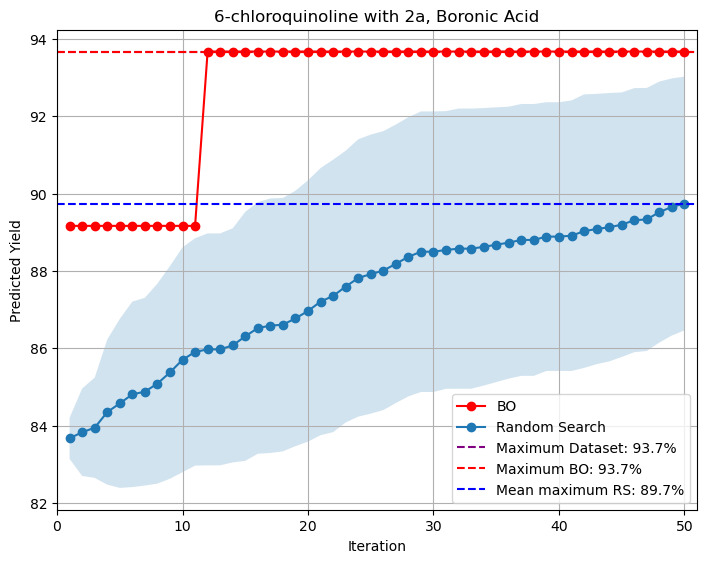

In [19]:
#encoded
reactant1_choice = '6-chloroquinoline'
reactant2_choice = '2a, Boronic Acid'

filtered = get_filtered(reactant1_choice, reactant2_choice, X_y).copy()
filtered.drop(['reactant1', 'reactant2'], axis = 1, inplace=True)
filtered.drop(descriptors_names, axis=1, inplace=True)
best_yield, observed = bo_comparison(filtered, max_iteration=50, seed=1)

max_value = filtered['yield_uv'].max()
rs_means, rs_stds = rs_comparison(filtered, 50, 100)
plot_comparison(best_yield, rs_means, rs_stds, reactant1_choice, reactant2_choice, get_fig=False, best_theoretical = max_value)

In [20]:
#one-hot encoding

# reactant1_choice_one_hot = f'reactant1_{reactant1_choice}'
# reactant2_choice_one_hot = f'reactant2_{reactant2_choice}'

# filtered_one_hot = get_filtered(reactant1_choice_one_hot, reactant2_choice_one_hot, X_y_one_hot, one_hot=True).copy()
# # yields_bo = np.zeros((10,50))

# best_yield_oh,_ = bo_comparison(filtered_one_hot, max_iteration=50, seed=1)

# max_value = filtered['yield_uv'].max()
# # mean_yields_bo = pd.DataFrame(yields_bo)
# # mean_yields_bo =  np.array([mean_yields_bo[x].mean() for x in range(50)])
# rs_means_oh, rs_stds_oh = rs_comparison(filtered, 50, 100)
# plot_comparison(best_yield_oh, rs_means_oh, rs_stds_oh, reactant1_choice, reactant2_choice, get_fig=False, best_theoretical = max_value)

In [21]:
failing_pairs = [('6-chloroquinoline', '2c, Trifluoroborate'), ('6-triflatequinoline', '2b, Boronic Ester'), ('6-triflatequinoline', '2c, Trifluoroborate'), ('6-Iodoquinoline', '2c, Trifluoroborate')]

Calculating the importances

In [22]:
importances = rf.feature_importances_

In [23]:
importances = pd.DataFrame({'Feature': X_stripped.columns, 'Gini Importance': importances}).sort_values('Gini Importance', ascending=False)

In [24]:
importances_no_reactants = importances[~importances['Feature'].str.startswith('reactant')]

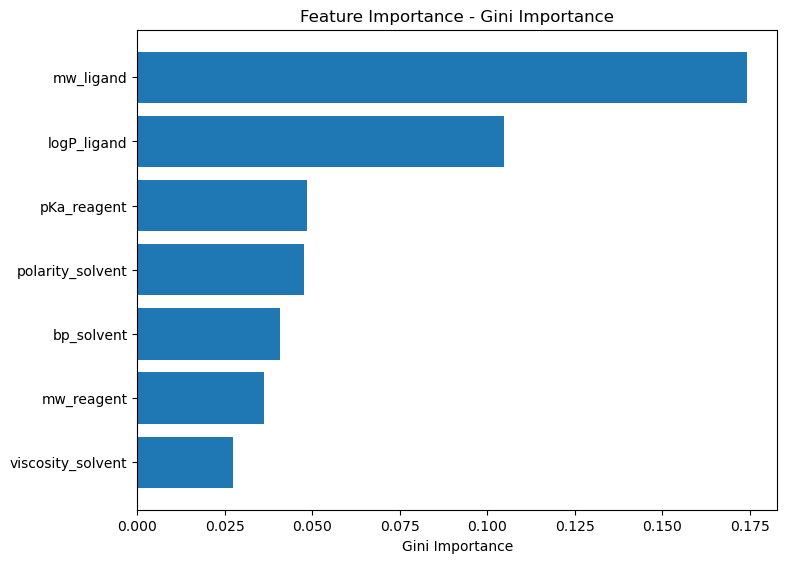

In [25]:
fig = plt.figure()
ax = fig.add_axes([0,0,1,1])
ax.barh(importances_no_reactants['Feature'][:7], importances_no_reactants['Gini Importance'][:7])
ax.set_xlabel('Gini Importance')
ax.set_title('Feature Importance - Gini Importance')
ax.invert_yaxis()
plt.show()

In [26]:
importances_no_reactants

,Feature,Gini Importance
7,mw_ligand,0.174146
8,logP_ligand,0.104722
5,pKa_reagent,0.048518
0,polarity_solvent,0.047658
2,bp_solvent,0.040764
4,mw_reagent,0.036262
3,viscosity_solvent,0.027274
6,solubility_h2o,0.025347
1,dielectric_solvent,0.019258
